# 🏨 Hotel Booking Demand Analysis  
## Week 1: Data Cleaning & Feature Engineering

### Objective:
To clean raw booking data, handle missing values, remove duplicates and outliers, and engineer meaningful features for analysis.

### Importing Libraries

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 📂 Data Loading

We load the raw hotel booking dataset and inspect its structure.

In [19]:
df=pd.read_csv(r'C:\Users\saofl\Downloads\Infotact Project 2_Hotel Booking\hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 🔍 Initial Data Exploration

We examine:
- Dataset shape  
- Data types  
- Summary statistics  
- Missing values  


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [21]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [22]:
df.shape

(119390, 32)

In [23]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

- Dataset contains 119,390 records and 32 features  
- Data includes both categorical and numerical variables  
- Initial inspection shows presence of missing values and potential inconsistencies

## 🧹 Handling Missing Values
We identified missing values in the following columns:
- `children`
- `country`
- `agent`
- `company`

In [24]:
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

In [25]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

- `children` → filled with 0  
- `country` → filled with 'Unknown'  
- `agent` & `company` → filled with 0 (indicating no agent/company involvement)

Missing values were not random but meaningful:
- Absence of agent/company indicates direct bookings  
- Filling values preserves dataset size without introducing bias

## 🔁 Duplicate Records Handling

In [26]:
df.duplicated().sum()

np.int64(31994)

In [27]:
dup_rows = df[df.duplicated()]
dup_rows.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,0.0,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,0.0,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,0.0,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,0.0,0,Transient,109.80,0,3,Check-Out,2015-07-08


In [28]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40772,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,0.0,0,Transient,75.0,0,1,Check-Out,2015-08-09
40802,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,0.0,0,Transient,75.0,0,1,Check-Out,2015-08-09
40821,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,0.0,0,Transient,89.0,0,1,Check-Out,2015-08-09
40838,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,0.0,0,Transient,89.0,0,1,Check-Out,2015-08-09
76792,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-08-11
76793,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-08-11
76794,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-08-11
41067,City Hotel,0,0,2015,August,33,11,0,1,1,...,No Deposit,0.0,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12
41073,City Hotel,0,0,2015,August,33,11,0,1,1,...,No Deposit,0.0,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12
41071,City Hotel,0,0,2015,August,33,11,0,1,2,...,No Deposit,0.0,0.0,0,Transient,80.0,0,0,Check-Out,2015-08-12


In [29]:
df = df.drop_duplicates().reset_index(drop=True)

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
original = 119390 
duplicates = 31994

print(f"{(duplicates/original)*100:.2f}% duplicates removed")

26.80% duplicates removed


In [32]:
df.shape

(87396, 32)

We identified duplicate rows in the dataset.


- Total duplicates found: 31,994 (~26.8% of dataset)


All exact duplicate rows were removed.


A significant portion of the dataset consisted of duplicate entries, which could have severely biased analysis results such as booking trends and cancellation rates.

## 📊 ADR Outlier Treatment

<Axes: ylabel='adr'>

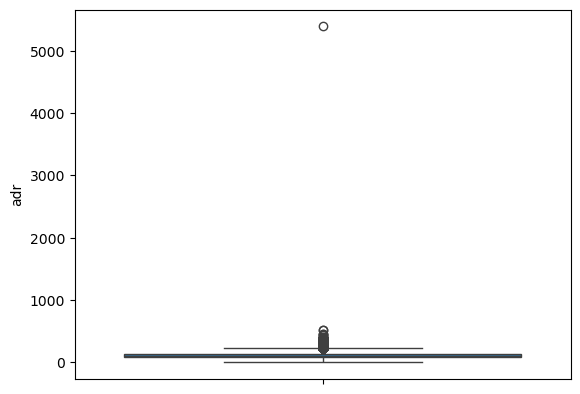

In [33]:
sns.boxplot(df['adr'])

In [34]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['adr'] >= lower_bound) & (df['adr'] <= upper_bound)]

In [35]:
print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (87396, 32)
After: (84906, 32)


In [41]:
df_clean[df_clean['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
11591,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,273.0,0.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [42]:
df_clean = df_clean[df_clean['adr'] >= 0]

In [43]:
df['adr'].describe()

count    87395.000000
mean       106.338536
std         55.012947
min          0.000000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64

In [44]:
df_clean[df_clean['adr'] == 0].shape

(1778, 32)

We analyzed the `adr` (Average Daily Rate) column using boxplots and statistical methods.

- Used IQR method to detect outliers  
- Removed extreme values above the upper bound  
- Removed invalid negative values  

- Most ADR values lie below 200  
- Extreme values (e.g., >5000) were identified as anomalies  
- Cleaning improved the reliability of pricing analysis

## ⚙️ Feature Engineering

In [47]:
#Total Stay
df_clean['total_stay'] = (
    df_clean['stays_in_weekend_nights'] +
    df_clean['stays_in_week_nights']
)
#Total Guests
df_clean['total_guests'] = (
    df_clean['adults'] +
    df_clean['children'] +
    df_clean['babies']
)

df_clean = df_clean[df_clean['total_guests'] > 0]
#is Family
df_clean['is_family'] = (
    (df_clean['children'] + df_clean['babies']) > 0
).astype(int)
#Lead Category
def lead_category(x):
    if x < 7:
        return 'Last_Minute'
    elif x < 30:
        return 'Short_Term'
    elif x < 90:
        return 'Medium_Term'
    else:
        return 'Long_Term'

df_clean['lead_category'] = df_clean['lead_time'].apply(lead_category)
#Arrival Date
df_clean['arrival_date'] = pd.to_datetime(
    df_clean['arrival_date_year'].astype(str) + '-' +
    df_clean['arrival_date_month'] + '-' +
    df_clean['arrival_date_day_of_month'].astype(str)
)
#Arrival Month
df_clean['arrival_month'] = df_clean['arrival_date'].dt.month
#Room Changed
df_clean['room_changed'] = (
    df_clean['reserved_room_type'] != df_clean['assigned_room_type']
).astype(int)
#Revenue
df_clean['revenue'] = df_clean['adr'] * df_clean['total_stay']

New features were created to enhance analysis:

- `total_stay` → total nights stayed  
- `total_guests` → total number of guests  
- `is_family` → indicates family bookings  
- `lead_category` → categorized booking lead time  
- `arrival_date` → combined date column  
- `arrival_month` → extracted month  
- `room_changed` → room reassignment indicator  
- `revenue` → estimated booking revenue  

Feature engineering transforms raw data into meaningful variables that improve interpretability and enable deeper business insights.

### Saving Cleaned Dataset

In [49]:
df_clean.to_csv(r"C:\Users\saofl\Downloads\Infotact Project 2_Hotel Booking\hotel_bookings_cleaned.csv", index=False)